# Example for VHEE dose calculation using pencilbeam engine.

This example demonstrates how to use the pyRadPlan library to perform dose calculations using the VHEE model.

IMPORTANT: Please use the ipopt optimizer, because scipy might not converge or converge to fast.
(Will be updated in the future)

To display this script in a Jupyter Notebook, you need to install jupytext via pip and run the following command.
This will create a .ipynb file in the same directory:

```bash
pip install jupytext
jupytext --to notebook path/to/this/file/pencilbeam_vhee.py

In [1]:
# Import necessary libraries
import logging

import numpy as np

from pyRadPlan import (
    IonPlan,
    generate_stf,
    calc_dose_influence,
    fluence_optimization,
    plot_slice,
    load_tg119,
)

from pyRadPlan.gui import launch_viewer, GUI_AVAILABLE
from pyRadPlan.optimization.objectives import SquaredDeviation, SquaredOverdosing

logging.basicConfig(level=logging.INFO)

C:\NiklasLocal\python\pyRadPlan\.venv313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load TG119 (provided within pyRadPlan)
ct, cst = load_tg119()

In this section, we create a VHEE therapy plan using the FermiEyges machine. </br>
We choose "Generic" for FermiEyges or "Focused" for a focused VHEE machine. </br>
We set the energy to 200 MeV, the bixel width to 5 mm and select 5 gantry angles with 72 degree spacing.

In [3]:
# Create a plan object - (VHEE | Generic) => FermiEyges
pln = IonPlan(radiation_mode="VHEE", machine="Generic")  # Alternative: Focused
pln.prop_opt = {"solver": "scipy"}  # better use IPOPT from ipyopt!

# Some specific Settings for VHEE
pln.prop_stf = {
    "energy": 200,  # set VHEE energy at [100, 150, 200] MeV
    "bixel_width": 5.0,
    "gantry_angles": [0, 72, 144, 216, 288],
    "couch_angles": [0, 0, 0, 0, 0],
}

# Setting the dose grid resolution
pln.prop_dose_calc = {"dose_grid": {"resolution": [5.0, 5.0, 5.0]}}

# Generate Steering Geometry ("stf")
stf = generate_stf(ct, cst, pln)

# Calculate Dose Influence Matrix ("dij")
dij = calc_dose_influence(ct, cst, stf, pln)

Beam:   0%|          | 0/5 [00:00<?, ?b/s]

Beam:  40%|████      | 2/5 [00:00<00:00, 10.86b/s]

Beam:  80%|████████  | 4/5 [00:00<00:00, 10.45b/s]

INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation using 'Hong Particle Pencil-Beam' Dose Engine...


INFO:pyRadPlan.dose.engines._base:Dose Grid has Dimensions (101,101,65) with resolution x=5.000000, y=5.000000, z=5.000000.


...

Ray:  92%|█████████▏| 262/284 [00:01<00:00, 257.58r/s]

Beam: 100%|██████████| 5/5 [00:05<00:00,  1.18s/b]

INFO:pyRadPlan.dose.engines._base_pencilbeam:Finalizing dose calculation...


INFO:pyRadPlan.dose.engines._base_pencilbeam:Done in 0.002187 seconds.


INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation done in 6.17 seconds.


Optimization

In [4]:
cst.vois[0].objectives = [SquaredOverdosing(priority=10.0, d_max=1.0)]  # OAR
cst.vois[1].objectives = [SquaredDeviation(priority=100.0, d_ref=3.0)]  # Target
cst.vois[2].objectives = [SquaredOverdosing(priority=10.0, d_max=2.0)]  # BODY

# Calculate optimized fluence
fluence = fluence_optimization(ct, cst, stf, dij, pln)

# Compute the result on the CT grid
result = dij.compute_result_ct_grid(fluence)

INFO:pyRadPlan.optimization.problems._optiprob:Converting all objectives to use quantity: physical_dose


INFO:pyRadPlan.dij._dij:Converted Dij to namespace 'array_api_compat.numpy'


INFO:pyRadPlan.quantities._base:Optimization will use array backend: array_api_compat.numpy


INFO:pyRadPlan.util.keyboard_listener:Press 'q' or ESC to stop optimization early.


INFO:pyRadPlan.optimization.solvers._base_solvers:Starting optimization using SciPy minimize


INFO:pyRadPlan.util.keyboard_listener:Optimization aborted by user. Returning last known iterate.


INFO:pyRadPlan.optimization.problems._nonlin_fluence:38 Objective function evaluations, avg. time: 0.00832724 +/- 0.000462057 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:38 Derivative evaluations, avg. time: 0.00945866 +/- 0.000488131 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:Solver time: 0.703937 s


Visualize the results

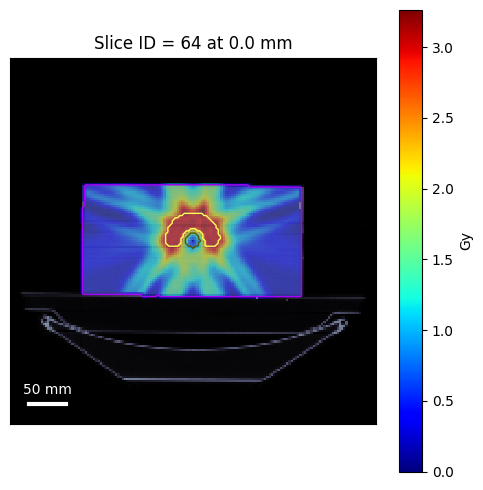

In [5]:
if GUI_AVAILABLE:
    # Use the GUI if [gui] dependencies are installed
    launch_viewer(ct, cst, result)
else:
    # Choose a slice to visualize
    view_slice = int(np.round(ct.size[2] / 2))

    # Visualize
    plot_slice(
        image_volume=ct,
        cst=cst,
        overlay=result["physical_dose"],
        view_slice=view_slice,
        plane="axial",
        overlay_unit="Gy",
    )